**Задание 1**

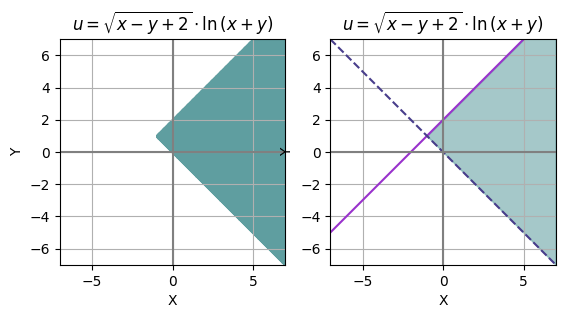

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

u_math = lambda x,y,module: math.sqrt(x-y+2)*math.log(x+y)

fig, (ax_dot,ax_plt) = plt.subplots(1,2)

x_np = np.arange(-7,7,.01)
y_np = np.arange(-7,9,.01)

x_plt = []
y_plt = []

for x in x_np:
    for y in y_np:
        try:
            u_try = u_math(x,y,math)
            x_plt.append(x)
            y_plt.append(y)
        except:
            ...

ax_dot.scatter(x_plt,y_plt,color='CadetBlue',s=.1)
ax_dot.axvline(0,color='gray')
ax_dot.axhline(0,color='gray')

ax_dot.set_title("$u = \sqrt{x-y+2}\cdot\ln{(x+y)}$")
ax_dot.set_aspect('equal',adjustable='box')
ax_dot.set_xlabel('X')
ax_dot.set_ylabel('Y')
ax_dot.set_xlim(-7,7)
ax_dot.set_ylim(-7,7)
ax_dot.grid()

x_plt  = x_np
y_plt1 = x_np + 2
y_plt2 = - x_np

ax_plt.plot(x_plt,y_plt1,color='DarkOrchid')
ax_plt.plot(x_plt,y_plt2,color='DarkSlateBlue',linestyle='--')

between_mask = x_plt > -1
ax_plt.fill_between(x_plt[between_mask],
                    y_plt2[between_mask],
                    y_plt1[between_mask],
                    color='CadetBlue',
                    alpha=.56            )

ax_plt.axvline(0,color='gray')
ax_plt.axhline(0,color='gray')

ax_plt.set_title("$u = \sqrt{x-y+2}\cdot\ln{(x+y)}$")
ax_plt.set_aspect('equal',adjustable='box')
ax_plt.set_xlabel('X')
ax_plt.set_ylabel('Y')
ax_plt.set_xlim(-7,7)
ax_plt.set_ylim(-7,7)
ax_plt.grid()

**Задание 2**

In [2]:
import math
import sympy as sp

z_real = math.sqrt(15.99 * 4.02)

x, y = sp.symbols('x y')
f    = sp.sqrt(x*y)

x0, y0 = 16,   4
dx, dy = -.01, .02

df_dx = sp.diff(f,x)
df_dy = sp.diff(f,y)
df    = df_dx*dx + df_dy*dy

z     = f.subs(x,x0).subs(y,y0)
dz    = df.subs(x,x0).subs(y,y0)
z_our = z + dz

print(f"Real Z: {z_real}")
print(f"Our  Z: {z_our}")
print(f"Difference: {abs(z_real-z_our)}")

Real Z: 8.01746842837563
Our  Z: 8.01750000000000
Difference: 0.0000315716243708408


**Задание 3**

In [3]:
import sympy as sp

def title_pprint(title,sp_obj):
    obj_str = sp.pretty(sp_obj).split('\n')
    print(*((' '*(len(title)+1))+s for s in obj_str[:-1]),sep='\n')
    print(title,obj_str[-1])

x, y = sp.symbols('x y')
z    = sp.exp(x)*sp.cos(y)

dx, dy = sp.symbols('dx dy')

dz_dx = sp.diff(z,x)
dz_dy = sp.diff(z,y)

dz = dz_dx*dx + dz_dy*dy

dz_dxdx = sp.diff(dz_dx,x)
dz_dxdy = sp.diff(dz_dx,y)
dz_dydy = sp.diff(dz_dy,y)

d2z = dz_dxdx*(dx**2) + 2*dz_dxdy*dx*dy + dz_dydy*(dy**2)

title_pprint("dz  = ",dz)
title_pprint("d²z = ",sp.simplify(d2z))

           x              x       
dz  =  dx⋅ℯ ⋅cos(y) - dy⋅ℯ ⋅sin(y)
       ⎛  2                             2       ⎞  x
d²z =  ⎝dx ⋅cos(y) - 2⋅dx⋅dy⋅sin(y) - dy ⋅cos(y)⎠⋅ℯ 


**Задание 4**

In [4]:
import sympy as sp

def title_pprint(title,sp_obj):
    obj_str = sp.pretty(sp_obj).split('\n')
    print(*((' '*(len(title)+1) if i != int(len(obj_str)/2) else title)+obj_str[i] \
          for i in range(len(obj_str))),sep='\n')

x, y, z = sp.symbols('x y z')
f       = x**2 + sp.sqrt(x*z)
F       = z - f

dx, dy = sp.symbols('dx dy')

F_x = sp.diff(F,x)
F_y = sp.diff(F,y)
F_z = sp.diff(F,z)

dz = -(F_x*dx + F_y*dy) / F_z

title_pprint("           dz = ",dz)
title_pprint("simplified dz = ",sp.simplify(dz))

                     ⎛         _____⎞ 
                     ⎜       ╲╱ x⋅z ⎟ 
                 -dx⋅⎜-2⋅x - ───────⎟ 
                     ⎝         2⋅x  ⎠ 
           dz = ─────────────────────
                            _____     
                          ╲╱ x⋅z      
                      1 - ───────     
                            2⋅z       
                      ⎛   2     _____⎞
                 dx⋅z⋅⎝4⋅x  + ╲╱ x⋅z ⎠
simplified dz = ─────────────────────
                     ⎛        _____⎞  
                   x⋅⎝2⋅z - ╲╱ x⋅z ⎠  


**Задание 5**

     ⎛        ____________________ ⎞
     ⎜ 2     ╱            4        ⎟
z1 = ⎜y    ╲╱  -24⋅x⋅y + y  + 432  ⎟
     ⎜── - ───────────────────────,⎟
     ⎝12             12            ⎠
     ⎛        ____________________ ⎞
     ⎜ 2     ╱            4        ⎟
z2 = ⎜y    ╲╱  -24⋅x⋅y + y  + 432  ⎟
     ⎜── + ───────────────────────,⎟
     ⎝12             12            ⎠


Text(0.5, 0, 'Z')

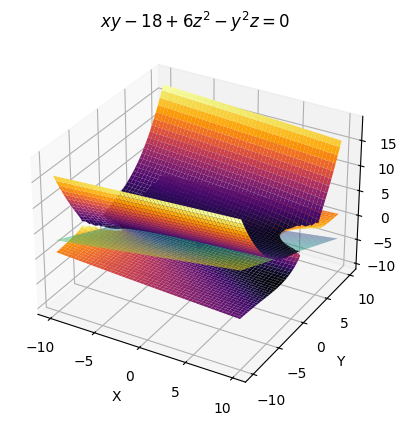

In [5]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

%matplotlib tk

def title_pprint(title,sp_obj):
    obj_str = sp.pretty(sp_obj).split('\n')
    print(*((' '*len(title) if i != int(len(obj_str)/2) else title)+obj_str[i] \
          for i in range(len(obj_str))),sep='\n')

x, y, z = sp.symbols('x y z')
F       = x*y - 18 + 6*(z**2)-(y**2)*z

z1, z2 = sp.solve((F,0),z)
title_pprint("z1 = ",z1)
title_pprint("z2 = ",z2)

z1_f = sp.lambdify((x,y),z1,'numpy')
z2_f = sp.lambdify((x,y),z2,'numpy')

fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')

x = np.arange(-10,10,.1)
y = np.arange(-10,10,.1)
x, y = np.meshgrid(x,y)

sqrt_guard = ((y**4) - 24*x*y + 432) >= 0

z             = np.full_like(x,np.nan)
z1            = z1_f(x[sqrt_guard],y[sqrt_guard])[0]
z[sqrt_guard] = z1
ax.plot_surface(x, y, z, cmap='inferno')

z             = np.full_like(x,np.nan)
z2            = z2_f(x[sqrt_guard],y[sqrt_guard])[0]
z[sqrt_guard] = z2
ax.plot_surface(x, y, z, cmap='inferno')

ax.scatter(1, -2, 1, color='DarkOrchid')

z = (2*x - 5*y - 4) / 8
ax.plot_surface(x, y, z, cmap='viridis', alpha=.56)

ax.quiver(1, -2, 1, -1, 3, 9, length=1.0, color='DarkOrchid')

ax.set_title('$xy - 18 + 6z^2 - y^2z = 0$')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

**Задание 6**

extrem 1 = (0, 0)
extrem 2 = (1, 1/2)


Text(0.5, 0, 'Z')

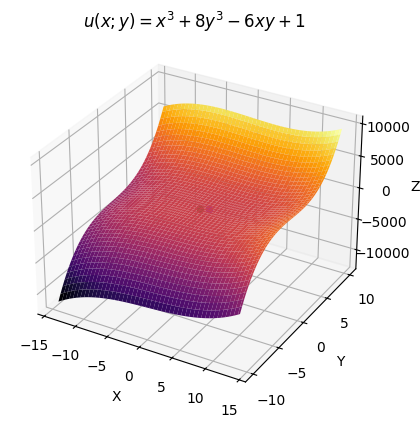

In [6]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

%matplotlib tk

def title_pprint(title,sp_obj):
    obj_str = sp.pretty(sp_obj).split('\n')
    print(*((' '*len(title) if i != int(len(obj_str)/2) else title)+obj_str[i] \
          for i in range(len(obj_str))),sep='\n')

z = lambda x,y: (x**3) + 8*(y**3) - 6*x*y + 1

x, y = sp.symbols('x y',real=True)
u    = z(x,y)

u_x = sp.diff(u,x)
u_y = sp.diff(u,y)

extrems = sp.solve((sp.Eq(u_x,0),sp.Eq(u_y,0)),(x,y))

for i in range(len(extrems)):
    title_pprint(f'extrem {i+1} = ',extrems[i])

fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')

x = np.arange(-14,14,.1)
y = np.arange(-10,10,.1)
x, y = np.meshgrid(x,y)

ax.plot_surface(x, y, z(x,y), cmap='inferno')

dot_colors = ['DarkOliveGreen','DarkOrchid']
for i in range(len(extrems)):
    ax.scatter(extrems[i][0],extrems[i][1],z(*extrems[i]),color=dot_colors[i])

ax.set_title('$u(x;y) = x^3 + 8y^3 - 6xy + 1$')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

**Задание 7**

Extrem 1 = (-12/7, 4/7)
D = 32/7
u_xx = -12/7
|| Local maximum
Extrem 2 = (-8/5, 2/5)
D = -32/5
u_xx = -12/5
|| No extremum
Extrem 3 = (-4/3, 2/3)
D = -32/3
u_xx = 4/3
|| No extremum
Extrem 4 = (0, 0)
D = 32
u_xx = 4
|| Local minimum


Text(0.5, 0, 'Z')

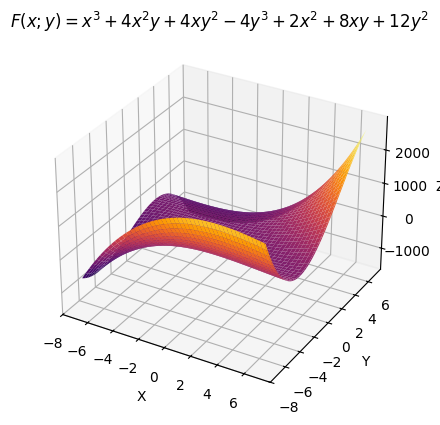

In [7]:
import math
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

%matplotlib tk

def title_pprint(title,sp_obj):
    obj_str = sp.pretty(sp_obj).split('\n')
    print(*((' '*len(title) if i != int(len(obj_str)/2) else title)+obj_str[i] \
          for i in range(len(obj_str))),sep='\n')

z = lambda x,y: (x**3) + 4*(x**2)*y + 4*x*(y**2) - 4*(y**3) + 2*(x**2) + 8*x*y + 12*(y**2)

x, y = sp.symbols('x y',real=True)
u    = z(x,y)

u_x = sp.diff(u,x)
u_y = sp.diff(u,y)

extrems = sp.solve((sp.Eq(u_x,0),sp.Eq(u_y,0)),(x,y))

u_xx = sp.diff(u_x,x)
u_xy = sp.diff(u_x,y)
u_yy = sp.diff(u_y,y)

D = u_xx*u_yy - (u_xy**2)

u_xx_f = sp.lambdify((x,y),u_xx,'math')
D_f    = sp.lambdify((x,y),D,'math')

for i in range(len(extrems)):
    title_pprint(f'Extrem {i+1} = ',extrems[i])
    D_    = D_f(*extrems[i])
    u_xx_ = u_xx_f(*extrems[i])
    print(f'D = {D_}\nu_xx = {u_xx_}')
    if   D_ > 0:
        if u_xx_ > 0: print('|| Local minimum')
        else:         print('|| Local maximum')
    elif D_ < 0:      print('|| No extremum')
    else:             print('|| Need additional inspection')
    

fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')

x = np.arange(-7,7,.1)
y = np.arange(-7,7,.1)
x, y = np.meshgrid(x,y)

ax.plot_surface(x, y, z(x,y), cmap='inferno')

dot_colors = ['DarkOliveGreen','DarkOrchid','DeepPink','DarkSlateBlue']
for i in range(len(extrems)):
    ax.scatter(extrems[i][0],extrems[i][1],z(*extrems[i]),color=dot_colors[i])

ax.set_title('$F(x;y) = x^3 + 4x^2y + 4xy^2 - 4y^3 + 2x^2 + 8xy + 12y^2$')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

**Задание 8**

          1       1 
       ──────── - ──
z_x  =        2    2
       (2 - x)    x 
          2       2 
       ──────── + ──
z_xx =        3    3
       (2 - x)    x 
Extrem (1, 1) is local minimum


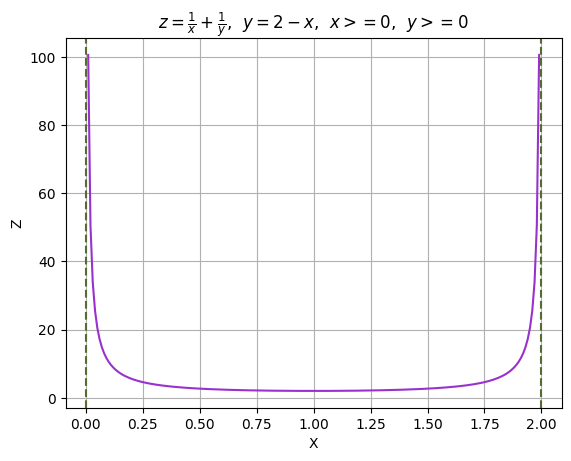

In [8]:
import math
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

def title_pprint(title,sp_obj):
    obj_str = sp.pretty(sp_obj).split('\n')
    print(*((' '*len(title) if i != int(len(obj_str)/2) else title)+obj_str[i] \
          for i in range(len(obj_str))),sep='\n')

x = np.arange(.01,2,.01)
y = 2 - x
z = 1/x + 1/y

plt.plot(x,z,color='DarkOrchid')

plt.axvline(0,color='DarkOliveGreen',linestyle='--')
plt.axvline(2,color='DarkOliveGreen',linestyle='--')

plt.title(r'$z = \frac{1}{x} + \frac{1}{y}$,  $y = 2 - x$,  $x >= 0$,  $y >= 0$')
plt.xlabel('X')
plt.ylabel('Z')
plt.grid()

x = sp.Symbol('x',positive=True)
y = 2 - x
z = 1/x + 1/y

z_x = sp.diff(z,x)
title_pprint('z_x  = ',z_x)

z_xx = sp.diff(z_x,x)
title_pprint('z_xx = ',z_xx)
z_xx_f = sp.lambdify(x,z_xx,'math')

y_f = sp.lambdify(x,y,'math')
extrems = [(x_,y_f(x_)) for x_ in sp.solve(sp.Eq(z_x,0),x)]

for extrem in extrems:
    z_xx_ = z_xx_f(extrem[0])
    if   z_xx_ > 0: type = 'local minimum'
    elif z_xx_ > 0: type = 'local maximum'
    else:           type = 'inflection point'
    print(f'Extrem {extrem} is {type}')